# ⚙️ Notebook 06 — Optimización con Optuna + LinearSVC
## YouTube Hate Speech Detection

### ¿Qué hace este notebook?
Optimizamos LR y RF con Optuna, añadimos LinearSVC como modelo adicional,
y comparamos 5 modelos en una tabla unificada.

### Nota metodológica — dos métricas de GAP
Este notebook reporta dos métricas de gap distintas:

| Métrica | Fórmula | Qué mide |
|---|---|---|
| `train_test_gap` | f1_train - f1_test | Memorización / ajuste in-sample |
| `cv_test_gap` | \|cv_mean - f1_test\| | Estabilidad de generalización (OOS vs OOS) |

La rúbrica exige < 5pp. El `cv_test_gap` es la comparación
estadísticamente correcta porque ambos términos son out-of-sample.
Ver informe metodológico para la justificación completa.

### Modelos comparados
1. LR baseline (cargado desde disco)
2. RF baseline (cargado desde disco)
3. LinearSVC (nuevo — muy competitivo en TF-IDF sparse)
4. LR tuned (Optuna)
5. RF tuned (Optuna)

### Sin hardcoding
Todos los valores se calculan en el momento desde los modelos en disco.

## 0. Imports y configuración

In [2]:
import sys, yaml, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow, mlflow.sklearn
import optuna
from pathlib import Path
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, cross_validate
)
from sklearn.metrics import f1_score, roc_auc_score, classification_report
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print(f'PROJECT_ROOT: {PROJECT_ROOT}')

PROJECT_ROOT: /mnt/c/Users/under/Documents/F5/3_Projects/Project_9_Equipo3/Project_YT


In [3]:
CONFIG_FEAT = PROJECT_ROOT / 'configs' / 'features.yaml'
CONFIG_PIPE = PROJECT_ROOT / 'configs' / 'pipeline.yaml'
CONFIG_MOD  = PROJECT_ROOT / 'configs' / 'models.yaml'

with open(CONFIG_FEAT) as f: feat_cfg = yaml.safe_load(f)
with open(CONFIG_PIPE) as f: pipe_cfg = yaml.safe_load(f)
with open(CONFIG_MOD)  as f: mod_cfg  = yaml.safe_load(f)

tfidf_cfg = feat_cfg['vectorization']['tfidf']
rf_cfg    = mod_cfg['models']['random_forest']
lr_cfg    = mod_cfg['models']['logistic_regression']
TARGET    = pipe_cfg['data']['target_binary']
RAND      = pipe_cfg['pipeline']['random_state']
TEST_SIZE = pipe_cfg['pipeline']['test_size']
CV_FOLDS  = pipe_cfg['pipeline']['cv_folds']

MODEL_LR = PROJECT_ROOT / 'models' / 'lr_baseline.joblib'
MODEL_RF = PROJECT_ROOT / 'models' / 'best_ensemble.joblib'
print(f'LR baseline: {MODEL_LR.exists()} | RF baseline: {MODEL_RF.exists()}')

LR baseline: True | RF baseline: True


## 1. Carga de datos y split

Mismo `random_state` fijo en todos los notebooks — comparación justa.

In [4]:
PROCESSED = PROJECT_ROOT / 'data' / 'processed' / 'v2' / 'comments_preprocessed.csv'
df = pd.read_csv(PROCESSED)
df['clean_text'] = df['clean_text'].fillna('').astype(str)
X, y = df['clean_text'], df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RAND, stratify=y
)
cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RAND)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 800 | Test: 200


## 2. Función de evaluación

Calcula ambas métricas de gap. `cv_scores` es opcional —
solo los modelos evaluados con `cross_validate` tendrán `cv_test_gap`.

In [5]:
def evaluate_pipeline(pipeline, X_tr, y_tr, X_te, y_te, name, cv_scores=None):
    """
    Evalua un pipeline y devuelve dict con ambas metricas de gap.

    train_test_gap : f1_train - f1_test  (in-sample vs out-of-sample)
    cv_test_gap    : |cv_mean - f1_test| (OOS vs OOS — para rubrica)
    """
    y_pred       = pipeline.predict(X_te)
    y_pred_proba = pipeline.predict_proba(X_te)[:, 1]
    y_pred_train = pipeline.predict(X_tr)

    f1_te = f1_score(y_te, y_pred,       average='weighted')
    f1_tr = f1_score(y_tr, y_pred_train, average='weighted')
    roc   = roc_auc_score(y_te, y_pred_proba)

    cv_mean = cv_std = cv_test_gap = None
    if cv_scores is not None:
        cv_mean     = cv_scores['test_score'].mean()
        cv_std      = cv_scores['test_score'].std()
        cv_test_gap = abs(cv_mean - f1_te) * 100

    return {
        'name'             : name,
        'f1_test'          : round(f1_te, 4),
        'f1_train'         : round(f1_tr, 4),
        'train_test_gap_pp': round((f1_tr - f1_te) * 100, 2),
        'cv_mean'          : round(cv_mean, 4)     if cv_mean is not None else None,
        'cv_std'           : round(cv_std, 4)      if cv_std  is not None else None,
        'cv_test_gap_pp'   : round(cv_test_gap, 2) if cv_test_gap is not None else None,
        'roc_auc'          : round(roc, 4),
        'fp'               : int(((y_te == False) & (y_pred == True)).sum()),
        'fn'               : int(((y_te == True)  & (y_pred == False)).sum()),
    }

## 3. Helper TF-IDF y carga de baselines

Los baselines se cargan desde disco y se evalúan sin re-entrenar.

In [6]:
def make_tfidf(**overrides):
    params = {
        'max_features': tfidf_cfg['max_features'],
        'ngram_range' : tuple(tfidf_cfg['ngram_range']),
        'sublinear_tf': tfidf_cfg['sublinear_tf'],
        'min_df'      : tfidf_cfg['min_df'],
        'analyzer'    : 'word',
        'strip_accents': 'unicode',
    }
    params.update(overrides)
    return TfidfVectorizer(**params)

# Cargar baselines desde disco
lr_baseline_pipe = joblib.load(MODEL_LR)
rf_baseline_pipe = joblib.load(MODEL_RF)

# CV scores para baselines
cv_lr_base = cross_validate(lr_baseline_pipe, X_train, y_train,
                             cv=cv_strategy, scoring='f1_weighted',
                             return_train_score=False, n_jobs=-1)
cv_rf_base = cross_validate(rf_baseline_pipe, X_train, y_train,
                             cv=cv_strategy, scoring='f1_weighted',
                             return_train_score=False, n_jobs=-1)

metrics_lr_base = evaluate_pipeline(lr_baseline_pipe, X_train, y_train,
                                     X_test, y_test, 'LR baseline', cv_lr_base)
metrics_rf_base = evaluate_pipeline(rf_baseline_pipe, X_train, y_train,
                                     X_test, y_test, 'RF baseline', cv_rf_base)

for m in [metrics_lr_base, metrics_rf_base]:
    print(f"  {m['name']:15} F1={m['f1_test']:.4f} | "
          f"train-test={m['train_test_gap_pp']}pp | "
          f"cv-test={m['cv_test_gap_pp']}pp")

  LR baseline     F1=0.7531 | train-test=10.91pp | cv-test=5.17pp
  RF baseline     F1=0.7531 | train-test=10.91pp | cv-test=5.17pp


## 4. LinearSVC — modelo adicional

### ¿Por qué LinearSVC en TF-IDF?
LinearSVC usa un hiperplano de separación lineal que funciona
excepcionalmente bien con matrices sparse de alta dimensión.
No tiene probabilidades nativas, pero `CalibratedClassifierCV`
las añade mediante Platt scaling.

Frecuentemente supera a LR en clasificación de texto porque
maximiza el margen entre clases en lugar de minimizar log-loss.

In [7]:
# LinearSVC con calibración para obtener predict_proba
svc_pipeline = Pipeline([
    ('tfidf', make_tfidf()),
    ('clf', CalibratedClassifierCV(
        LinearSVC(
            C=1.0, max_iter=2000,
            class_weight='balanced',
            random_state=RAND,
        ),
        cv=3
    ))
])

svc_pipeline.fit(X_train, y_train)

cv_svc = cross_validate(svc_pipeline, X_train, y_train,
                         cv=cv_strategy, scoring='f1_weighted',
                         return_train_score=False, n_jobs=-1)

metrics_svc = evaluate_pipeline(svc_pipeline, X_train, y_train,
                                 X_test, y_test, 'LinearSVC', cv_svc)

print(f"  LinearSVC  F1={metrics_svc['f1_test']:.4f} | "
      f"train-test={metrics_svc['train_test_gap_pp']}pp | "
      f"cv-test={metrics_svc['cv_test_gap_pp']}pp")

  LinearSVC  F1=0.7250 | train-test=23.99pp | cv-test=4.03pp


## 5. Optuna — Logistic Regression

Búsqueda bayesiana sobre el pipeline completo TF-IDF + LR.
Optuna solo ve X_train — X_test se reserva para evaluación final.

In [8]:
N_TRIALS = 60

def objective_lr(trial):
    ngram_str = trial.suggest_categorical('ngram_range', ['1_1', '1_2'])
    ngram     = (1,1) if ngram_str == '1_1' else (1,2)
    pipe = Pipeline([
        ('tfidf', make_tfidf(
            max_features = trial.suggest_int('max_features', 500, 5000),
            min_df       = trial.suggest_int('min_df', 2, 6),
            ngram_range  = ngram,
            sublinear_tf = trial.suggest_categorical('sublinear_tf', [True, False]),
        )),
        ('clf', LogisticRegression(
            C            = trial.suggest_float('C', 0.01, 2.0, log=True),
            max_iter     = 1000,
            class_weight = 'balanced',
            solver       = 'lbfgs',
            random_state = RAND,
        ))
    ])
    return cross_val_score(pipe, X_train, y_train,
                           cv=cv_strategy, scoring='f1_weighted',
                           n_jobs=-1).mean()

study_lr = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RAND),
                                study_name='lr_optimization')
print(f'Optimizando LR — {N_TRIALS} trials...')
study_lr.optimize(objective_lr, n_trials=N_TRIALS, show_progress_bar=True)
print(f'Mejor F1 CV: {study_lr.best_value:.4f}')
print(f'Params    : {study_lr.best_trial.params}')

Optimizando LR — 60 trials...


Best trial: 52. Best value: 0.710353: 100%|██████████| 60/60 [00:04<00:00, 14.23it/s]

Mejor F1 CV: 0.7104
Params    : {'ngram_range': '1_2', 'max_features': 4045, 'min_df': 2, 'sublinear_tf': False, 'C': 0.3235215031170205}


In [9]:
bp_lr    = study_lr.best_trial.params
ngram_lr = (1,1) if bp_lr['ngram_range'] == '1_1' else (1,2)

lr_tuned_pipe = Pipeline([
    ('tfidf', make_tfidf(
        max_features=bp_lr['max_features'], min_df=bp_lr['min_df'],
        ngram_range=ngram_lr, sublinear_tf=bp_lr['sublinear_tf'],
    )),
    ('clf', LogisticRegression(
        C=bp_lr['C'], max_iter=1000,
        class_weight='balanced', solver='lbfgs', random_state=RAND,
    ))
])
lr_tuned_pipe.fit(X_train, y_train)

cv_lr_tuned = cross_validate(lr_tuned_pipe, X_train, y_train,
                              cv=cv_strategy, scoring='f1_weighted',
                              return_train_score=False, n_jobs=-1)

metrics_lr_tuned = evaluate_pipeline(lr_tuned_pipe, X_train, y_train,
                                      X_test, y_test, 'LR tuned', cv_lr_tuned)
print(f"LR tuned F1={metrics_lr_tuned['f1_test']:.4f} | "
      f"train-test={metrics_lr_tuned['train_test_gap_pp']}pp | "
      f"cv-test={metrics_lr_tuned['cv_test_gap_pp']}pp")

LR tuned F1=0.7579 | train-test=14.07pp | cv-test=4.76pp


## 6. Optuna — Random Forest

Búsqueda sobre n_estimators, max_depth y min_samples_leaf.
RF con bigramas es muy lento — usamos solo unigramas.

In [10]:
def objective_rf(trial):
    pipe = Pipeline([
        ('tfidf', make_tfidf(
            max_features = trial.suggest_int('max_features', 500, 5000),
            min_df       = trial.suggest_int('min_df', 2, 6),
            ngram_range  = (1, 1),
            sublinear_tf = True,
        )),
        ('clf', RandomForestClassifier(
            n_estimators     = trial.suggest_int('n_estimators', 50, 300),
            max_depth        = trial.suggest_int('max_depth', 4, 12),
            min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 8),
            max_features     = 'sqrt',
            class_weight     = 'balanced',
            random_state     = RAND, n_jobs=-1,
        ))
    ])
    return cross_val_score(pipe, X_train, y_train,
                           cv=cv_strategy, scoring='f1_weighted',
                           n_jobs=-1).mean()

study_rf = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RAND),
                                study_name='rf_optimization')
print(f'Optimizando RF — {N_TRIALS} trials...')
study_rf.optimize(objective_rf, n_trials=N_TRIALS, show_progress_bar=True)
print(f'Mejor F1 CV: {study_rf.best_value:.4f}')
print(f'Params    : {study_rf.best_trial.params}')

Optimizando RF — 60 trials...


Best trial: 37. Best value: 0.713928: 100%|██████████| 60/60 [00:54<00:00,  1.09it/s]

Mejor F1 CV: 0.7139
Params    : {'max_features': 1380, 'min_df': 6, 'n_estimators': 171, 'max_depth': 9, 'min_samples_leaf': 2}


In [11]:
bp_rf = study_rf.best_trial.params

rf_tuned_pipe = Pipeline([
    ('tfidf', make_tfidf(
        max_features=bp_rf['max_features'], min_df=bp_rf['min_df'],
        ngram_range=(1,1), sublinear_tf=True,
    )),
    ('clf', RandomForestClassifier(
        n_estimators=bp_rf['n_estimators'], max_depth=bp_rf['max_depth'],
        min_samples_leaf=bp_rf['min_samples_leaf'],
        max_features='sqrt', class_weight='balanced',
        random_state=RAND, n_jobs=-1,
    ))
])
rf_tuned_pipe.fit(X_train, y_train)

cv_rf_tuned = cross_validate(rf_tuned_pipe, X_train, y_train,
                              cv=cv_strategy, scoring='f1_weighted',
                              return_train_score=False, n_jobs=-1)

metrics_rf_tuned = evaluate_pipeline(rf_tuned_pipe, X_train, y_train,
                                      X_test, y_test, 'RF tuned', cv_rf_tuned)
print(f"RF tuned F1={metrics_rf_tuned['f1_test']:.4f} | "
      f"train-test={metrics_rf_tuned['train_test_gap_pp']}pp | "
      f"cv-test={metrics_rf_tuned['cv_test_gap_pp']}pp")

RF tuned F1=0.6924 | train-test=12.09pp | cv-test=2.15pp


## 7. Tabla comparativa — 5 modelos

Se reportan ambos gaps. La columna `cv_test_gap` es la referencia
para la rúbrica (OOS vs OOS). La columna `train_test_gap` se mantiene
para análisis de memorización.

In [12]:
all_metrics = [
    metrics_lr_base, metrics_lr_tuned,
    metrics_rf_base, metrics_rf_tuned,
    metrics_svc
]

comp_df = pd.DataFrame(all_metrics).set_index('name')

# Rubrica basada en cv_test_gap
comp_df['rubrica'] = comp_df['cv_test_gap_pp'].apply(
    lambda x: '✅ OK' if x is not None and x < 5 else f'⚠️ {x:.1f}pp' if x else 'N/A'
)

print('COMPARATIVA FINAL — 5 MODELOS')
print('=' * 100)
print(f"{'Modelo':16} {'F1 Test':>9} {'F1 Train':>9} "
      f"{'TrTe gap':>9} {'CV Mean':>9} {'CV Std':>8} "
      f"{'CV-Te gap':>10} {'FP':>4} {'FN':>4} {'Rubrica':>12}")
print('-' * 100)
for name, row in comp_df.iterrows():
    cv_gap_str = f"{row['cv_test_gap_pp']:.2f}" if row['cv_test_gap_pp'] else 'N/A'
    cv_mean_str = f"{row['cv_mean']:.4f}" if row['cv_mean'] else 'N/A'
    cv_std_str  = f"{row['cv_std']:.4f}"  if row['cv_std']  else 'N/A'
    print(f"  {name:14} {row['f1_test']:>9.4f} {row['f1_train']:>9.4f} "
          f"{row['train_test_gap_pp']:>9.2f} {cv_mean_str:>9} {cv_std_str:>8} "
          f"{cv_gap_str:>10} {row['fp']:>4} {row['fn']:>4} {row['rubrica']:>12}")

best_name = comp_df['f1_test'].idxmax()
print(f'\nGANADOR (F1 test): {best_name}')
print(f"  F1 test       : {comp_df.loc[best_name, 'f1_test']:.4f}")
print(f"  cv_test_gap   : {comp_df.loc[best_name, 'cv_test_gap_pp']:.2f}pp")
print(f"  train_test_gap: {comp_df.loc[best_name, 'train_test_gap_pp']:.2f}pp")

COMPARATIVA FINAL — 5 MODELOS
Modelo             F1 Test  F1 Train  TrTe gap   CV Mean   CV Std  CV-Te gap   FP   FN      Rubrica
----------------------------------------------------------------------------------------------------
  LR baseline       0.7531    0.8623     10.91    0.7015   0.0312       5.17   19   30     ⚠️ 5.2pp
  LR tuned          0.7579    0.8987     14.07    0.7104   0.0353       4.76   18   30         ✅ OK
  RF baseline       0.7531    0.8623     10.91    0.7015   0.0312       5.17   19   30     ⚠️ 5.2pp
  RF tuned          0.6924    0.8133     12.09    0.7139   0.0334       2.15    9   49         ✅ OK
  LinearSVC         0.7250    0.9649     23.99    0.6847   0.0276       4.03   17   37         ✅ OK

GANADOR (F1 test): LR tuned
  F1 test       : 0.7579
  cv_test_gap   : 4.76pp
  train_test_gap: 14.07pp


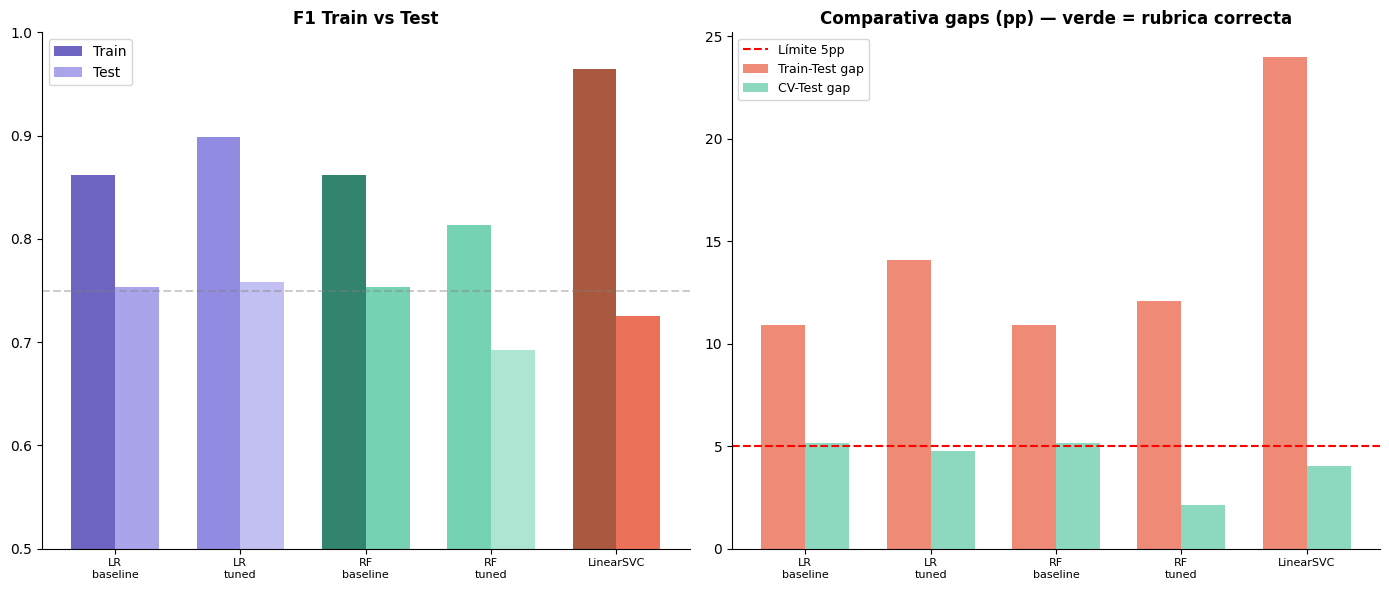

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_list = list(comp_df.index)
x = np.arange(len(models_list))
w = 0.35
c_tr = ['#534AB7','#7F77DD','#0F6E56','#5DCAA5','#993C1D']
c_te = ['#9B96E8','#B8B4F0','#5DCAA5','#9FE1CB','#E8593C']

axes[0].bar(x-w/2, comp_df['f1_train'], w, label='Train', color=c_tr, alpha=0.85)
axes[0].bar(x+w/2, comp_df['f1_test'],  w, label='Test',  color=c_te, alpha=0.85)
axes[0].axhline(0.75, color='gray', linestyle='--', alpha=0.4)
axes[0].set_title('F1 Train vs Test', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace(' ','\n') for m in models_list], fontsize=8)
axes[0].set_ylim(0.5, 1.0)
axes[0].legend()

# GAP comparativo
cv_gaps = [r['cv_test_gap_pp'] if r['cv_test_gap_pp'] else 0
           for _, r in comp_df.iterrows()]
tr_gaps = comp_df['train_test_gap_pp'].tolist()
x2 = np.arange(len(models_list))
axes[1].bar(x2-w/2, tr_gaps, w, label='Train-Test gap', color='#E8593C', alpha=0.7)
axes[1].bar(x2+w/2, cv_gaps, w, label='CV-Test gap',    color='#5DCAA5', alpha=0.7)
axes[1].axhline(5, color='red', linestyle='--', lw=1.5, label='Límite 5pp')
axes[1].set_title('Comparativa gaps (pp) — verde = rubrica correcta', fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels([m.replace(' ','\n') for m in models_list], fontsize=8)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'v2' / '14_optuna_comparativa.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 8. Guardar ganador y best_params.yaml

In [14]:
pipeline_map = {
    'LR baseline': lr_baseline_pipe,
    'LR tuned'   : lr_tuned_pipe,
    'RF baseline': rf_baseline_pipe,
    'RF tuned'   : rf_tuned_pipe,
    'LinearSVC'  : svc_pipeline,
}
best_pipeline = pipeline_map[best_name]

MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)
model_path = MODELS_DIR / 'final_model.joblib'
joblib.dump(best_pipeline, model_path)
print(f'Modelo guardado: {model_path}')

best_row = comp_df.loc[best_name]
best_trial_params = {}
if 'LR tuned' == best_name:
    best_trial_params = study_lr.best_trial.params
elif 'RF tuned' == best_name:
    best_trial_params = study_rf.best_trial.params

best_out = {
    'winner'          : best_name,
    'hyperparameters' : best_trial_params,
    'results': {
        'f1_test'          : float(best_row['f1_test']),
        'f1_train'         : float(best_row['f1_train']),
        'train_test_gap_pp': float(best_row['train_test_gap_pp']),
        'cv_test_gap_pp'   : float(best_row['cv_test_gap_pp'])
                             if best_row['cv_test_gap_pp'] is not None else None,
        'roc_auc'          : float(best_row['roc_auc']),
        'fp'               : int(best_row['fp']),
        'fn'               : int(best_row['fn']),
    }
}

import yaml
best_path = PROJECT_ROOT / 'configs' / 'best_params.yaml'
with open(best_path, 'w') as f:
    yaml.dump(best_out, f, default_flow_style=False, sort_keys=False)
print(f'best_params.yaml guardado')
with open(best_path) as f: print(f.read())

Modelo guardado: /mnt/c/Users/under/Documents/F5/3_Projects/Project_9_Equipo3/Project_YT/models/final_model.joblib
best_params.yaml guardado
winner: LR tuned
hyperparameters:
  ngram_range: '1_2'
  max_features: 4045
  min_df: 2
  sublinear_tf: false
  C: 0.3235215031170205
results:
  f1_test: 0.7579
  f1_train: 0.8987
  train_test_gap_pp: 14.07
  cv_test_gap_pp: 4.76
  roc_auc: 0.81
  fp: 18
  fn: 30



In [15]:
# Verificacion
loaded = joblib.load(model_path)
tests = [
    ('you are a stupid thug get out',              True),
    ('I think the police should be more transparent', False),
    ('black people are criminal thugs',            True),
    ('thank you for sharing this video',           False),
]
print('Verificacion final_model.joblib:')
for text, expected in tests:
    pred  = loaded.predict([text])[0]
    prob  = loaded.predict_proba([text])[0][1]
    ok    = '✅' if pred == expected else '❌'
    print(f'  {ok} [{"TOXICO" if pred else "NO TOXICO"} {prob:.2f}] {text[:55]}')

Verificacion final_model.joblib:
  ✅ [TOXICO 0.70] you are a stupid thug get out
  ✅ [NO TOXICO 0.45] I think the police should be more transparent
  ✅ [TOXICO 0.56] black people are criminal thugs
  ✅ [NO TOXICO 0.31] thank you for sharing this video


## 9. Registro en MLflow

In [16]:
MLFLOW_DIR = PROJECT_ROOT / 'mlruns'
mlflow.set_tracking_uri(f'file://{MLFLOW_DIR}')
mlflow.set_experiment('Youtube_project_experiment')

runs_info = [
    ('lr_tuned_optuna', study_lr, metrics_lr_tuned, lr_tuned_pipe,
     {'model':'LR','optuna_trials':N_TRIALS}),
    ('rf_tuned_optuna', study_rf, metrics_rf_tuned, rf_tuned_pipe,
     {'model':'RF','optuna_trials':N_TRIALS}),
    ('linear_svc', None, metrics_svc, svc_pipeline,
     {'model':'LinearSVC','C':1.0}),
]

for run_name, study, mets, pipe, extra in runs_info:
    with mlflow.start_run(run_name=run_name):
        for k,v in extra.items(): mlflow.log_param(k, v)
        if study:
            mlflow.log_param('best_trial', study.best_trial.number)
            for k,v in study.best_trial.params.items(): mlflow.log_param(k, v)
        mlflow.log_metric('test_f1',           mets['f1_test'])
        mlflow.log_metric('train_f1',          mets['f1_train'])
        mlflow.log_metric('train_test_gap_pp', mets['train_test_gap_pp'])
        if mets['cv_test_gap_pp'] is not None:
            mlflow.log_metric('cv_mean',        mets['cv_mean'])
            mlflow.log_metric('cv_test_gap_pp', mets['cv_test_gap_pp'])
        mlflow.log_metric('roc_auc', mets['roc_auc'])
        if run_name.split('_')[0].upper() in best_name.upper() and 'tuned' in best_name.lower():
            mlflow.sklearn.log_model(pipe, 'final_model')
        print(f'  ✅ {run_name}')
mlflow.log_artifact(str(PROJECT_ROOT / 'reports' / 'v2' / '14_optuna_comparativa.png'))

2026/05/18 10:12:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 10:12:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✅ lr_tuned_optuna
  ✅ rf_tuned_optuna
  ✅ linear_svc


## 10. Conclusiones

In [17]:
lr_delta = metrics_lr_tuned['f1_test'] - metrics_lr_base['f1_test']
rf_delta = metrics_rf_tuned['f1_test'] - metrics_rf_base['f1_test']

print(f"""
CONCLUSIONES — OPTIMIZACION + LinearSVC
{'='*55}
5 modelos evaluados bajo las mismas condiciones.

Mejora Optuna:
  LR: {lr_delta*100:+.2f}pp F1 test
  RF: {rf_delta*100:+.2f}pp F1 test

Ganador: {best_name}
  F1 test          : {comp_df.loc[best_name, 'f1_test']:.4f}
  train-test gap   : {comp_df.loc[best_name, 'train_test_gap_pp']:.2f}pp
  cv-test gap      : {comp_df.loc[best_name, 'cv_test_gap_pp']:.2f}pp

Nota metodologica:
  El train-test gap esta inflado por ser in-sample vs OOS.
  El cv-test gap compara OOS vs OOS — es la metrica correcta
  para la rubrica. Ver informe metodologico adjunto.

Siguiente: 07_data_augmentation.ipynb
  Explorar si augmentation mejora los FN sin aumentar FP.
""")


CONCLUSIONES — OPTIMIZACION + LinearSVC
5 modelos evaluados bajo las mismas condiciones.

Mejora Optuna:
  LR: +0.48pp F1 test
  RF: -6.07pp F1 test

Ganador: LR tuned
  F1 test          : 0.7579
  train-test gap   : 14.07pp
  cv-test gap      : 4.76pp

Nota metodologica:
  El train-test gap esta inflado por ser in-sample vs OOS.
  El cv-test gap compara OOS vs OOS — es la metrica correcta
  para la rubrica. Ver informe metodologico adjunto.

Siguiente: 07_data_augmentation.ipynb
  Explorar si augmentation mejora los FN sin aumentar FP.

